In [7]:
import os
import nilearn
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting
import numpy as np
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn.plotting import plot_contrast_matrix
from nilearn.image import resample_img
from nilearn import masking
from nilearn.image import new_img_like
from natsort import natsorted

In [2]:
maskDir = 'F:\yujun\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)
# view = plotting.view_img(mask)
# view

In [3]:
nii_tmp = nib.load(r'F:\yujun\projects\AI_IAPS\GLM\betas\Sub1\beta_0001.nii')

In [4]:
# Resample the MNI mask to match the dimensions and voxel size of your NIfTI file
mni_mask_resampled = resample_img(mask, target_affine=nii_tmp.affine, target_shape=nii_tmp.shape)
mni_mask_resampled.shape
# view = plotting.view_img(mni_mask_resampled)

(79, 95, 79)

In [8]:
data_dir = 'F:\yujun\projects\LAB_IAPS_AI\preprocessed_fMRIdata\dev-sess\Sub2\Run01'
niifilenames = natsorted(os.listdir(data_dir))
selected_filenames = [file for file in niifilenames if file.startswith('swar')]
selected_filenames

['swarfdev_003-0005-00001-000001-01.nii',
 'swarfdev_003-0005-00002-000002-01.nii',
 'swarfdev_003-0005-00003-000003-01.nii',
 'swarfdev_003-0005-00004-000004-01.nii',
 'swarfdev_003-0005-00005-000005-01.nii',
 'swarfdev_003-0005-00006-000006-01.nii',
 'swarfdev_003-0005-00007-000007-01.nii',
 'swarfdev_003-0005-00008-000008-01.nii',
 'swarfdev_003-0005-00009-000009-01.nii',
 'swarfdev_003-0005-00010-000010-01.nii',
 'swarfdev_003-0005-00011-000011-01.nii',
 'swarfdev_003-0005-00012-000012-01.nii',
 'swarfdev_003-0005-00013-000013-01.nii',
 'swarfdev_003-0005-00014-000014-01.nii',
 'swarfdev_003-0005-00015-000015-01.nii',
 'swarfdev_003-0005-00016-000016-01.nii',
 'swarfdev_003-0005-00017-000017-01.nii',
 'swarfdev_003-0005-00018-000018-01.nii',
 'swarfdev_003-0005-00019-000019-01.nii',
 'swarfdev_003-0005-00020-000020-01.nii',
 'swarfdev_003-0005-00021-000021-01.nii',
 'swarfdev_003-0005-00022-000022-01.nii',
 'swarfdev_003-0005-00023-000023-01.nii',
 'swarfdev_003-0005-00024-000024-0

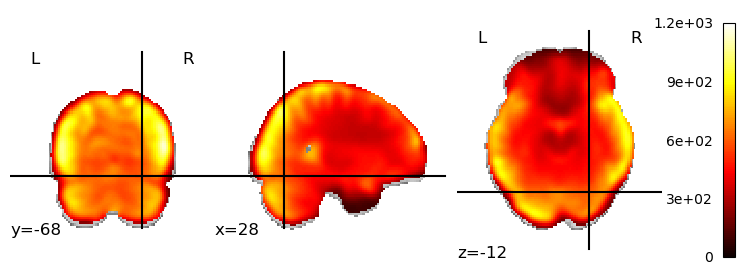

In [15]:
file_path2 = 'F:\yujun\projects\LAB_IAPS_AI\preprocessed_fMRIdata\dev-sess\Sub1\Run01\swarfdev_001-0005-00087-000087-01.nii'
nii_data2 = nib.load(file_path2)
# Apply the mask to the NIfTI image
masked_data = masking.apply_mask(nii_data2, mni_mask_resampled)
# Get the mask's indices in the original 3D shape
mask_indices = np.where(mni_mask_resampled.get_fdata())
# Create a new 3D array filled with zeros
reshaped_data = np.zeros(nii_data2.shape)
# Fill the new 3D array with the values from the masked data
reshaped_data[mask_indices] = masked_data
beta_nii = new_img_like(nii_data2, reshaped_data)
plotting.plot_stat_map(beta_nii, threshold=1, cut_coords = [28, -68,-12])

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\displays\_slicers.py:144: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  figure = plt.figure(figure, figsize=figsize,


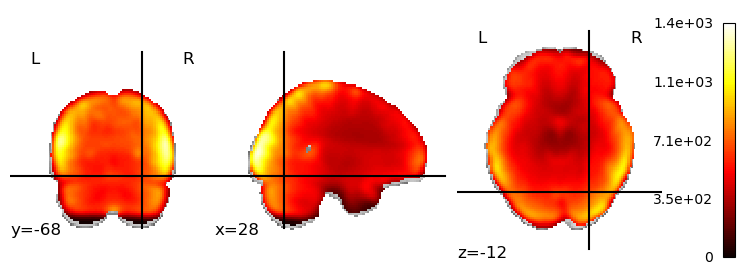

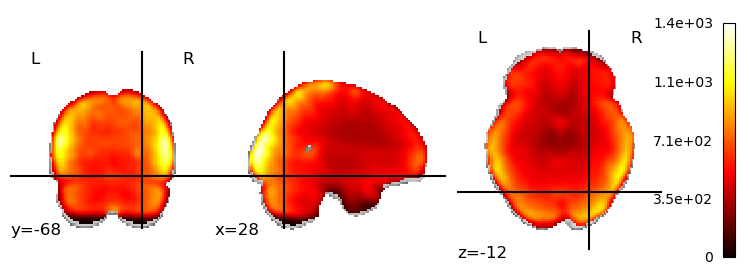

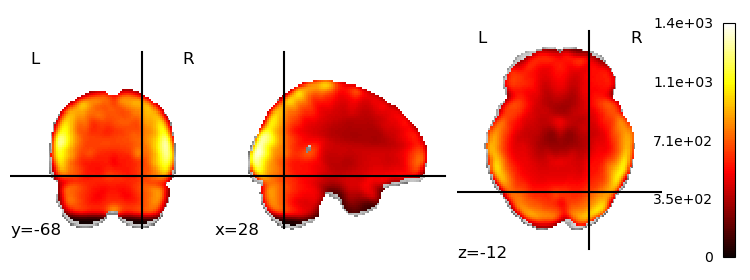

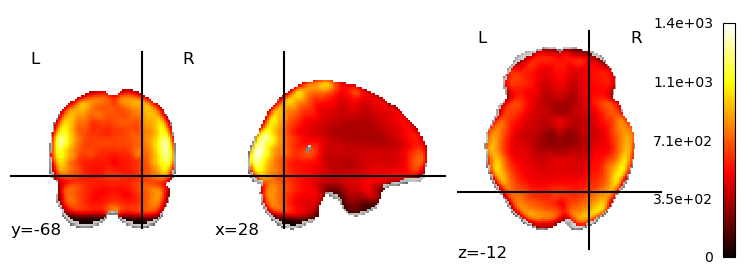

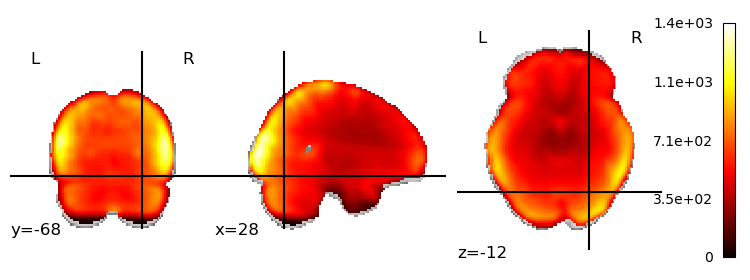

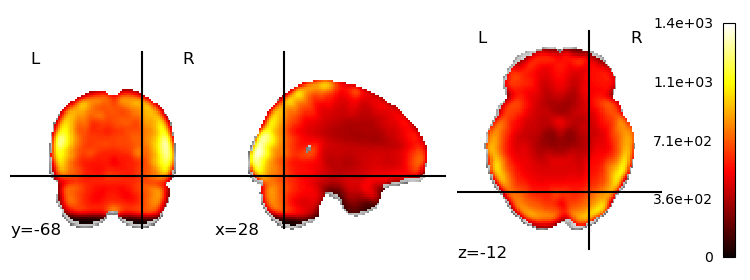

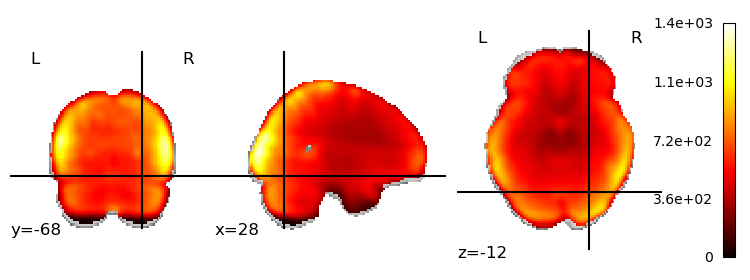

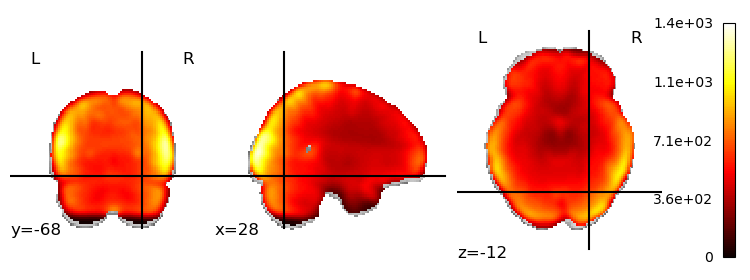

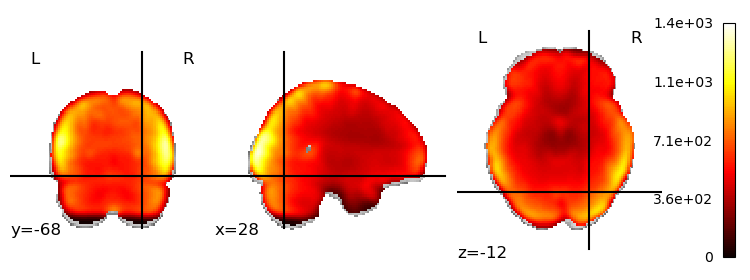

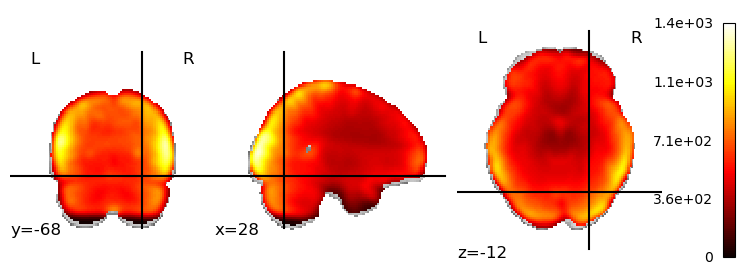

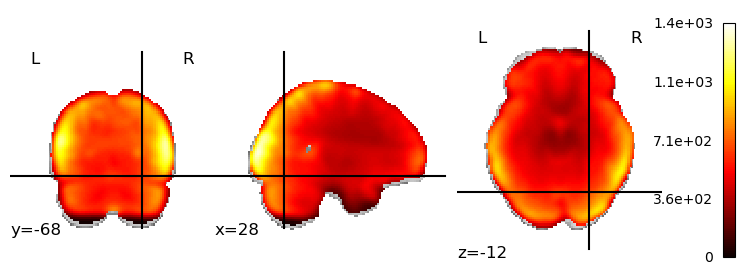

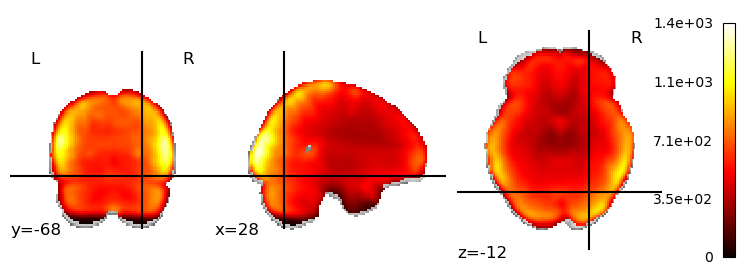

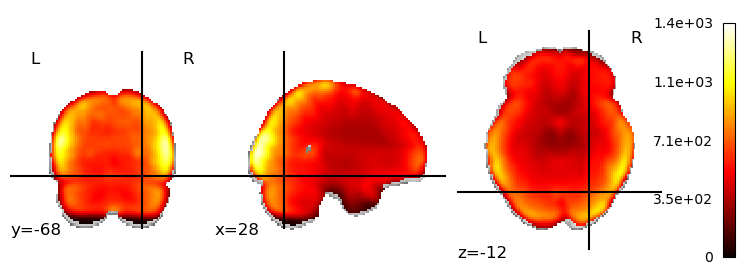

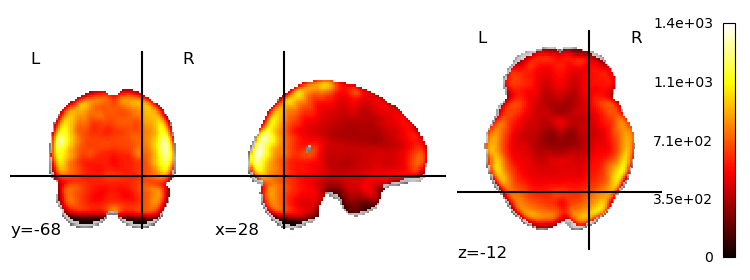

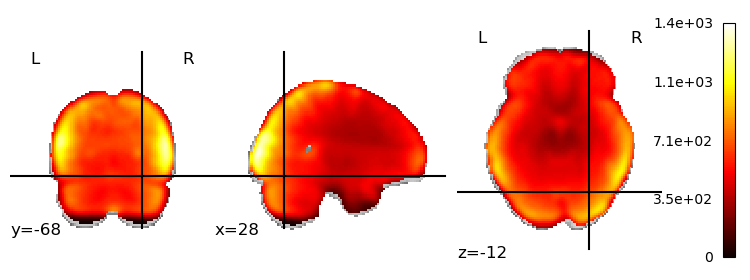

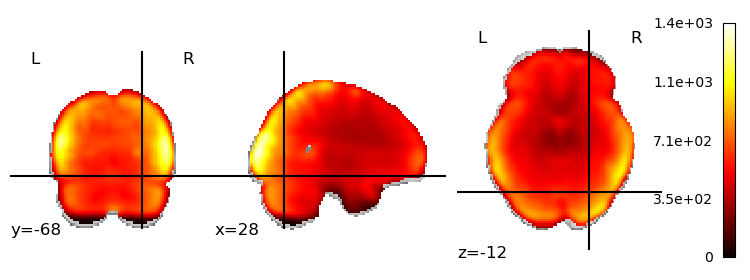

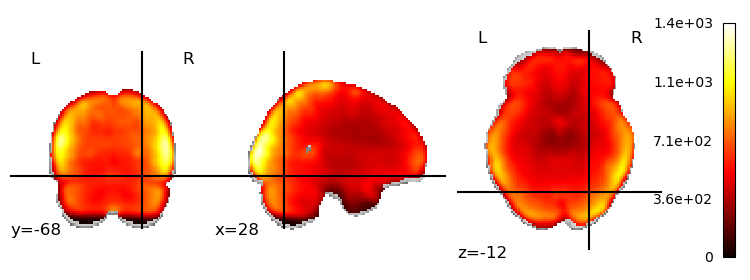

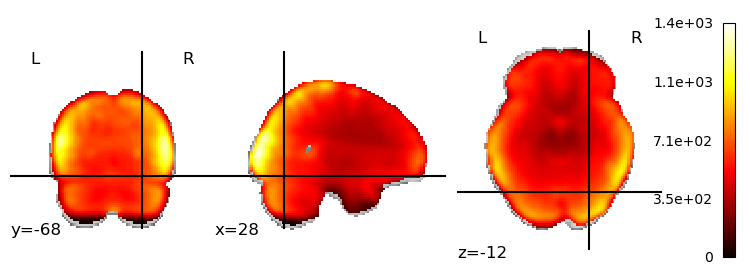

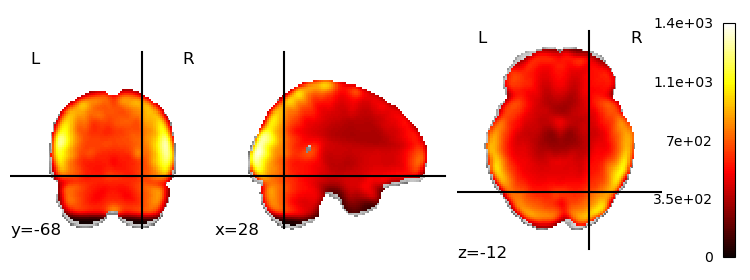

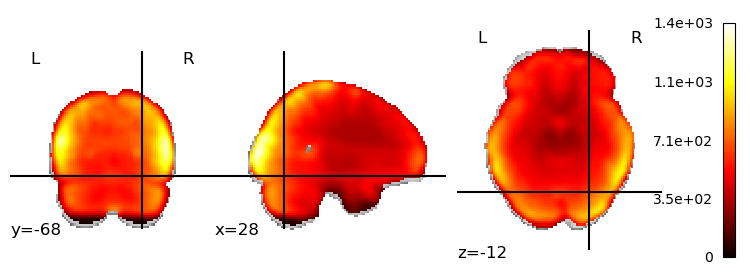

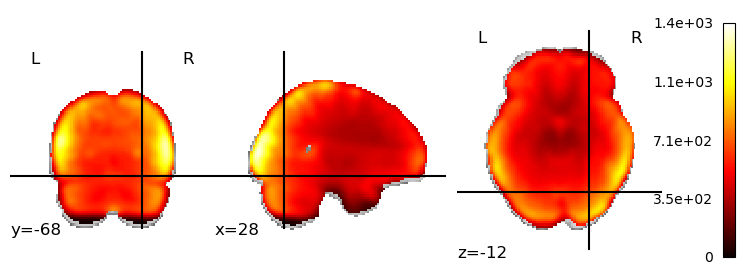

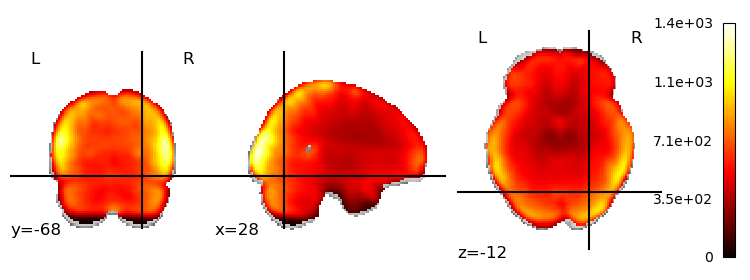

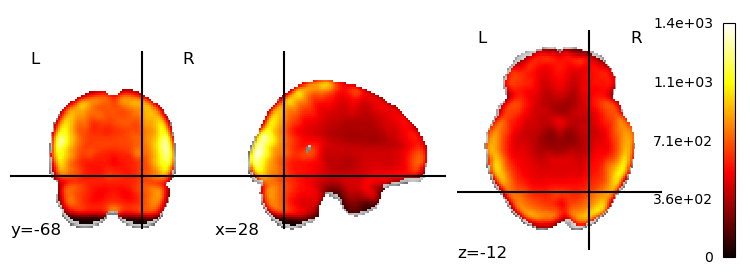

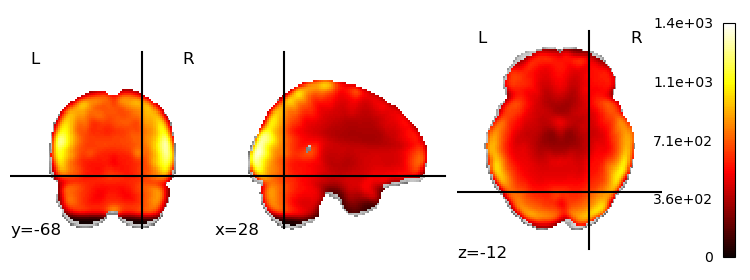

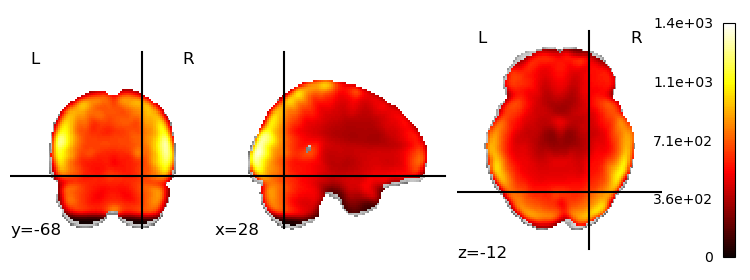

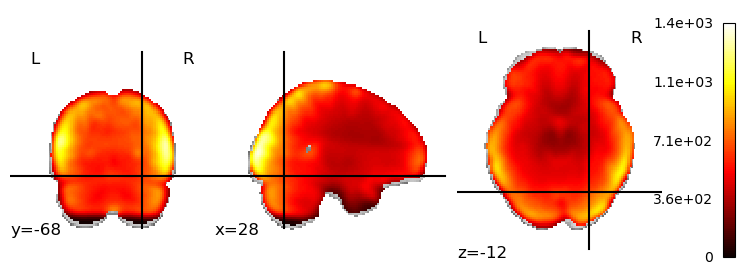

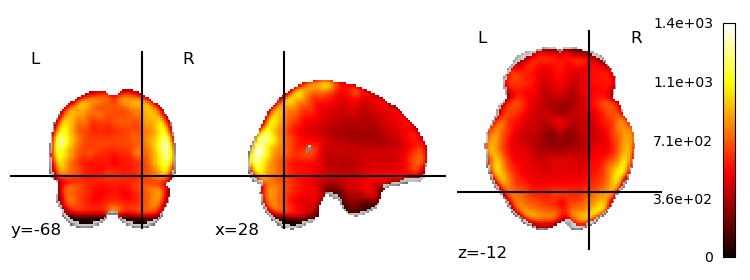

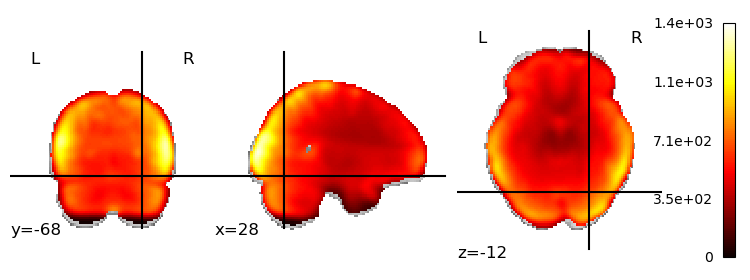

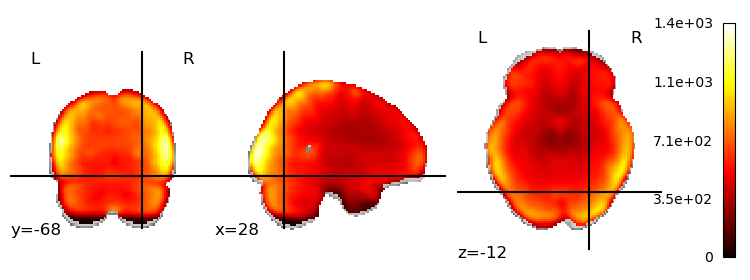

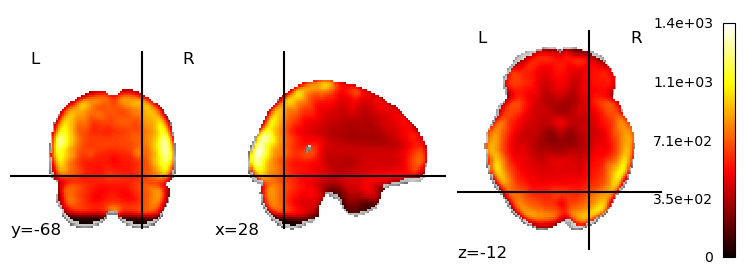

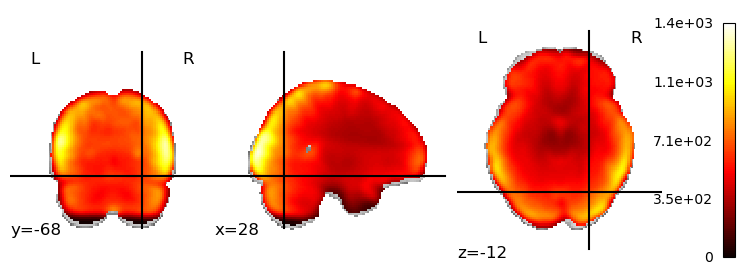

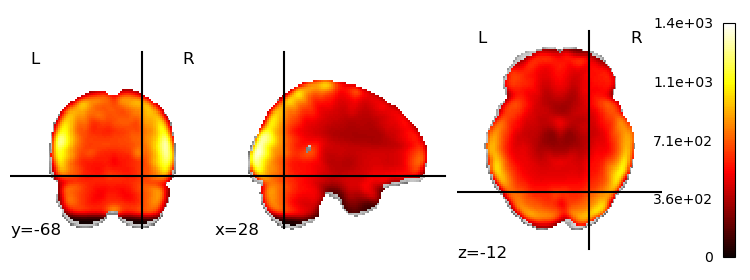

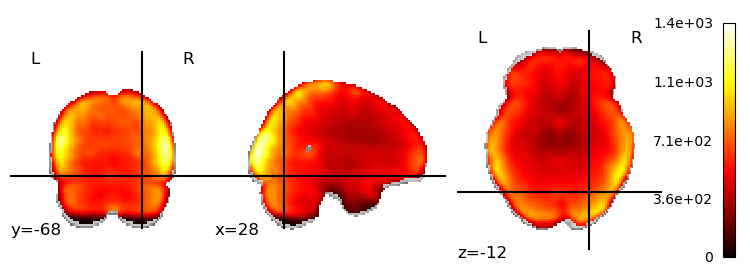

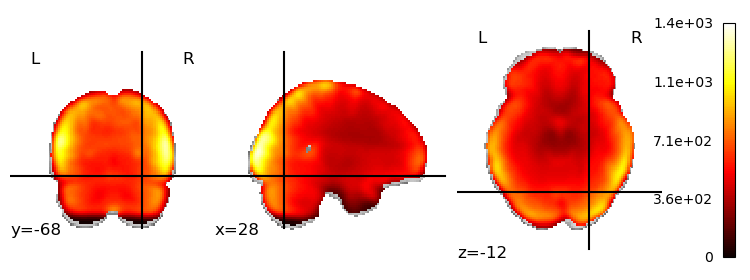

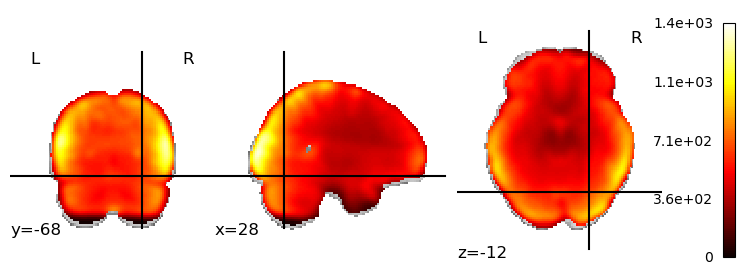

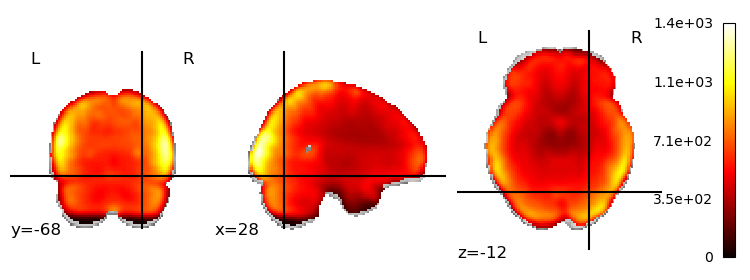

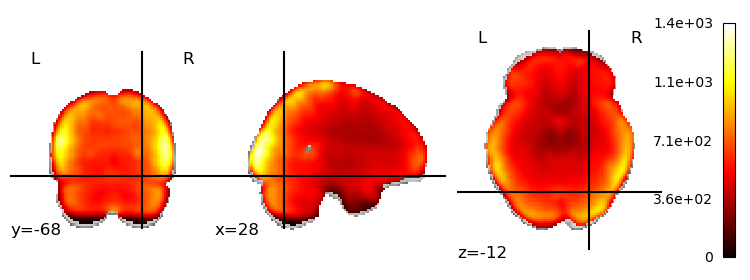

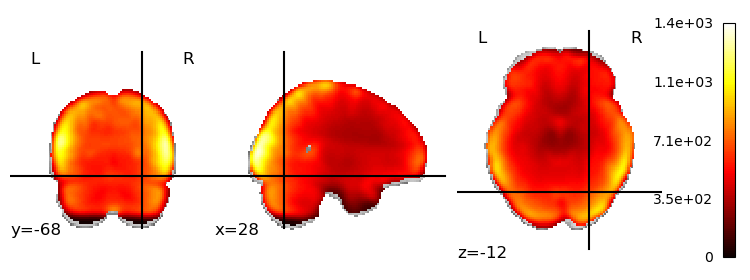

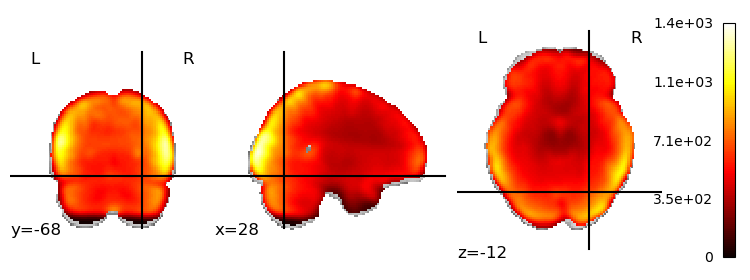

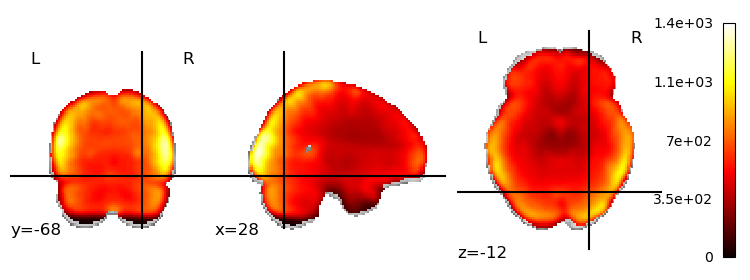

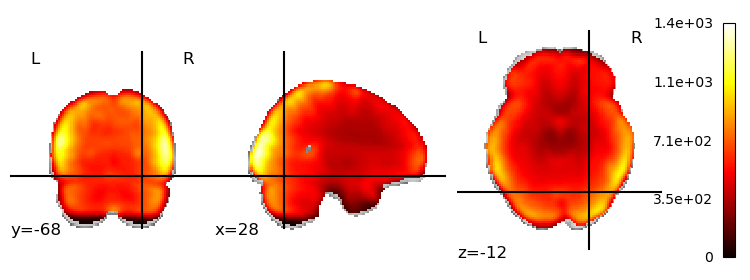

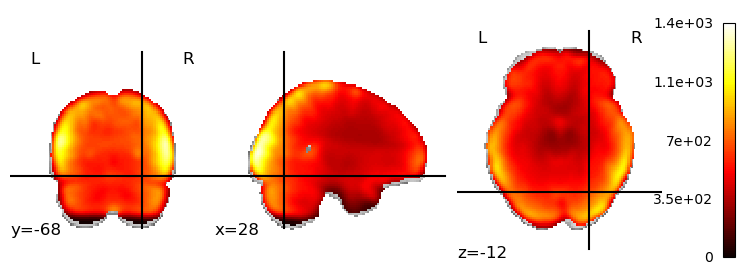

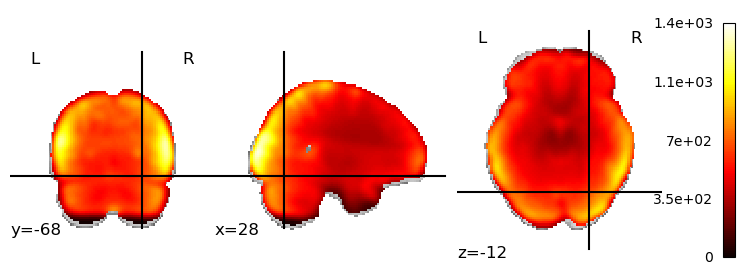

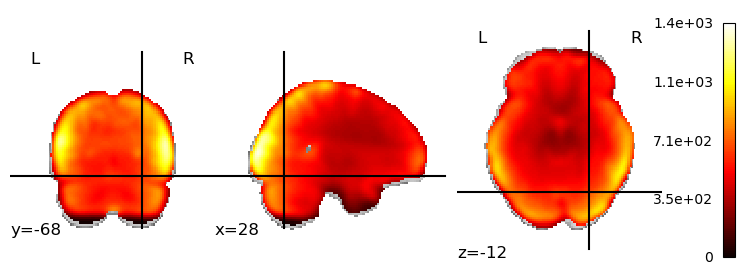

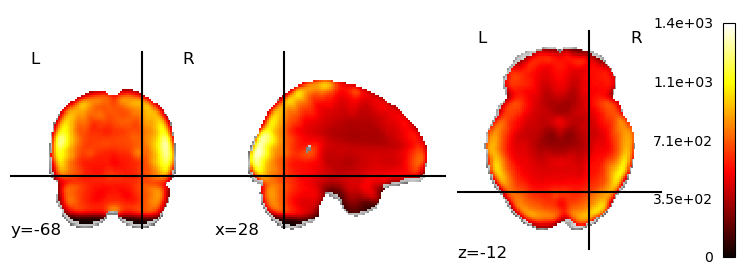

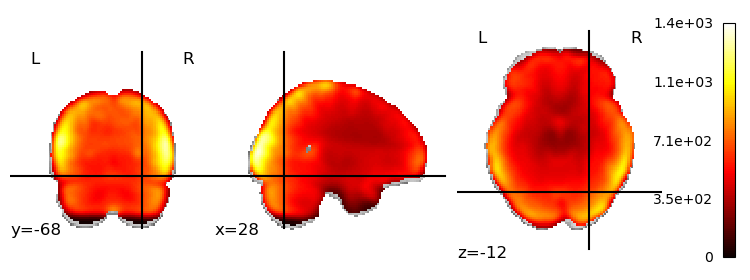

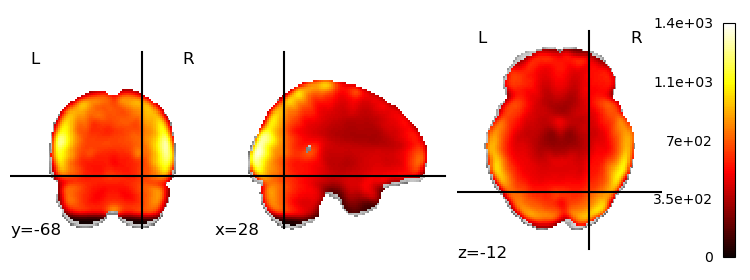

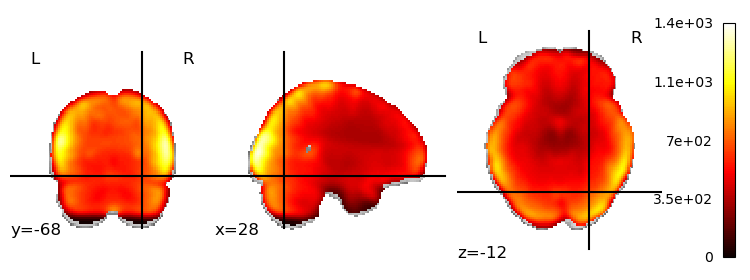

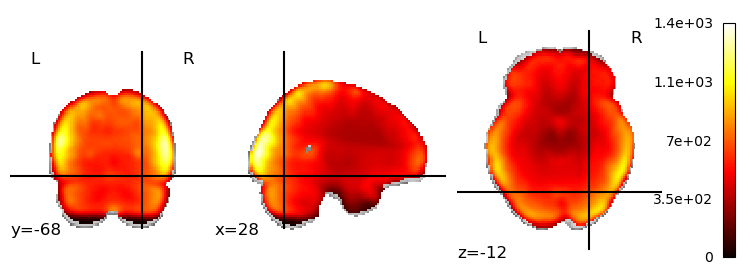

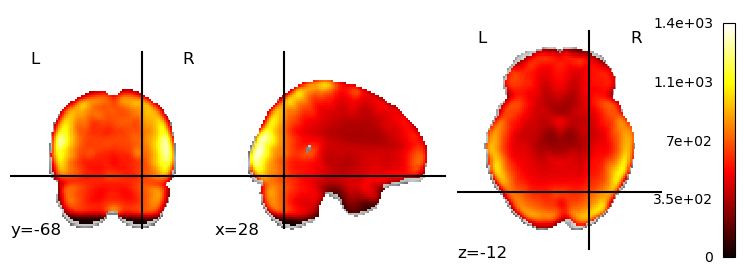

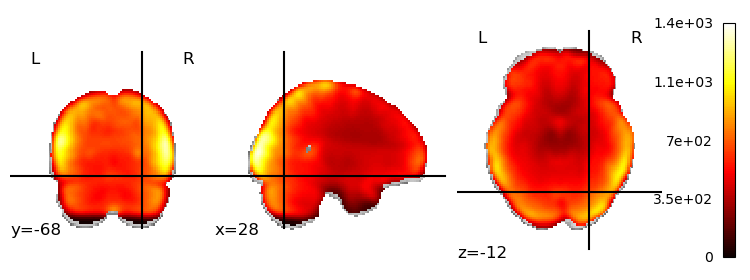

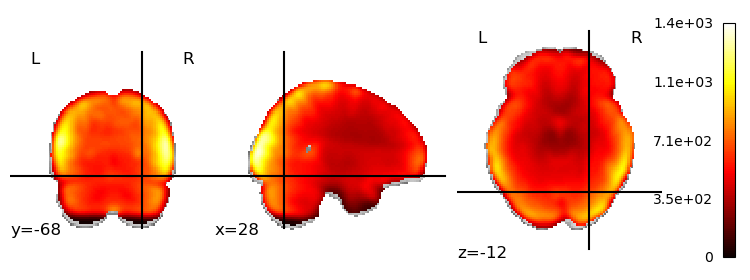

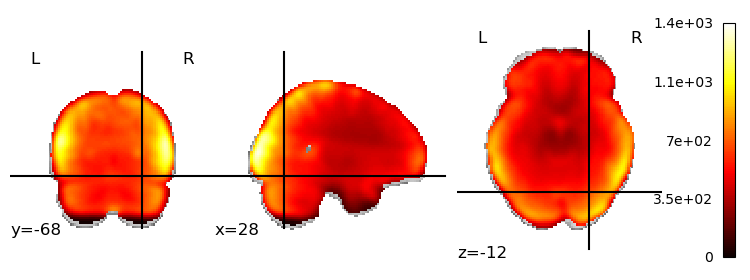

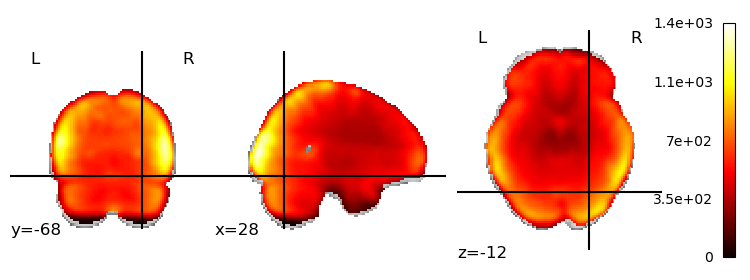

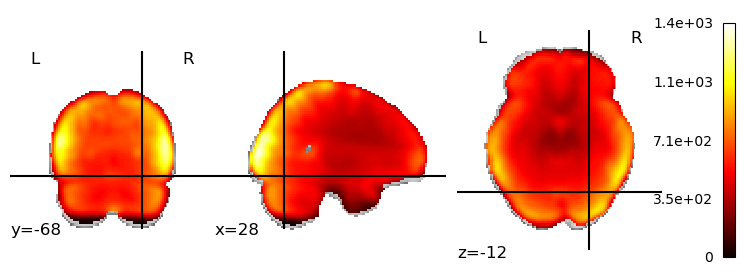

In [9]:
for i in range(55):

    file_path2 = os.path.join(data_dir, selected_filenames[i])
    nii_data2 = nib.load(file_path2)
    # Apply the mask to the NIfTI image
    masked_data = masking.apply_mask(nii_data2, mni_mask_resampled)
    # Get the mask's indices in the original 3D shape
    mask_indices = np.where(mni_mask_resampled.get_fdata())
    # Create a new 3D array filled with zeros
    reshaped_data = np.zeros(nii_data2.shape)
    # Fill the new 3D array with the values from the masked data
    reshaped_data[mask_indices] = masked_data
    beta_nii = new_img_like(nii_data2, reshaped_data)
    plotting.plot_stat_map(beta_nii, threshold=1, cut_coords = [28, -68,-12])

plotting.show()